In [1]:
import pandas as pd

In [72]:
train=pd.read_csv(r'C:\Users\rahul\Desktop\vscode_files\test_deployment\data\raw\Train.csv')
test=pd.read_csv(r'C:\Users\rahul\Desktop\vscode_files\test_deployment\data\raw\Test.csv')

In [73]:
def show(df):
    print(" ")
    print(df.info())
    print(" ")
    print(df.describe())
    print(" ")
    print("empty", df.isnull().sum())
    print(" ")
    print(df['Segmentation'].value_counts(normalize=True))
    print(" ")
    
show(train)

 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB
None
 
                  ID          Age  Work_Experience  Family_Size
count    8068.000000  8068.000000      7239.000000  7733.000000
mean   463479.214551    43.466906         2.641663     2.850123
std      2595.381232    16.711

In [74]:
train.shape

(8068, 11)

In [75]:
8068-335

7733

In [76]:
train=train.dropna()
train.isnull().sum()

ID                 0
Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
Segmentation       0
dtype: int64

In [77]:
train.shape

(6665, 11)

In [78]:
df=pd.read_csv(r'C:\Users\rahul\Desktop\vscode_files\test_deployment\data\raw\Train.csv')

In [79]:
df.columns

Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='object')

<Axes: xlabel='Work_Experience', ylabel='Density'>

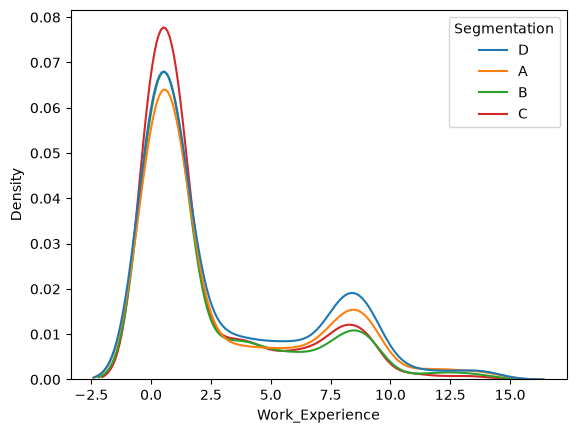

In [80]:
import seaborn as sns
sns.kdeplot(df,x=df['Work_Experience'],hue=df['Segmentation'], color='r')

In [81]:
df['Work_Experience'].describe()

count    7239.000000
mean        2.641663
std         3.406763
min         0.000000
25%         0.000000
50%         1.000000
75%         4.000000
max        14.000000
Name: Work_Experience, dtype: float64

In [82]:
train.groupby('Segmentation').agg({'Work_Experience':['mean','median','std']})

Work_Experience                 
                        mean median       std
Segmentation                                 
A                   2.888614    1.0  3.627206
B                   2.393766    1.0  3.246823
C                   2.224419    1.0  3.036655
D                   2.997154    1.0  3.611468

In [83]:
import mlflow
mlflow.set_tracking_uri("https://dagshub.com/Rahulkumar1029/test_deployment.mlflow")
import dagshub
dagshub.init(repo_owner='Rahulkumar1029', repo_name='test_deployment', mlflow=True)
experiment_name = "test_deployment"
mlflow.set_experiment(experiment_name)
with mlflow.start_run():
  mlflow.log_param('parameter name', 'value')
  mlflow.log_metric('metric name', 1)

ConnectTimeout: _ssl.c:989: The handshake operation timed out

In [ ]:
train.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
5,461319,Male,Yes,56,No,Artist,0.0,Average,2.0,Cat_6,C
6,460156,Male,No,32,Yes,Healthcare,1.0,Low,3.0,Cat_6,C


In [ ]:
train=train[['Work_Experience','Family_Size','Age']].astype('int')

In [ ]:
train.head()

,Work_Experience,Family_Size,Age
0,1,4,22
2,1,1,67
3,0,2,67
5,0,2,56
6,1,3,32


In [ ]:
train['Var_1'].value_counts(normalize=True)

Var_1
Cat_6    0.671568
Cat_4    0.127382
Cat_3    0.095124
Cat_2    0.054314
Cat_7    0.024906
Cat_1    0.015604
Cat_5    0.011103
Name: proportion, dtype: float64

In [ ]:
train=train[train['Var_1']=="Cat_2"]

In [ ]:
train

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
